Importing LIbraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

Data Obzervartion

In [4]:
df = pd.read_csv("TRAIN.csv")
df.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


In [5]:
df.tail()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
188335,T1188336,149,S2,L3,R2,2019-05-31,1,Yes,51,37272.00
188336,T1188337,153,S4,L2,R1,2019-05-31,1,No,90,54572.64
188337,T1188338,154,S1,L3,R2,2019-05-31,1,No,56,31624.56
188338,T1188339,155,S3,L1,R2,2019-05-31,1,Yes,70,49162.41
188339,T1188340,152,S2,L1,R1,2019-05-31,1,No,47,37977.00


In [6]:
print("Shape:", df.shape)

Shape: (188340, 10)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB


In [8]:
df.describe()

,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


In [9]:
df.describe(include='object')

,ID,Store_Type,Location_Type,Region_Code,Date,Discount
count,188340,188340,188340,188340,188340,188340
unique,188340,4,5,4,516,2
top,T1188340,S1,L1,R1,2019-05-31,No
freq,1,88752,85140,63984,365,104051


In [10]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("Zero-sales rows:", (df['Sales'] == 0).sum())
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Unique stores:", df['Store_id'].nunique())

Missing values:
 ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

Duplicates: 0
Zero-sales rows: 19
Date range: 2018-01-01 to 2019-05-31
Unique stores: 365


Insights:
- No missing values
- 19 zero-sales days (~0.01%) likely represent closed stores.

### Feature Engineering (Date Column)

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Mon, 6=Sun
df['DayName'] = df['Date'].dt.day_name()
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales,Year,Month,Day,DayOfWeek,DayName,WeekOfYear,IsWeekend
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84,2018,1,1,0,Monday,1,0
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12,2018,1,1,0,Monday,1,0
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20,2018,1,1,0,Monday,1,0
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16,2018,1,1,0,Monday,1,0
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52,2018,1,1,0,Monday,1,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ID             188340 non-null  object        
 1   Store_id       188340 non-null  int64         
 2   Store_Type     188340 non-null  object        
 3   Location_Type  188340 non-null  object        
 4   Region_Code    188340 non-null  object        
 5   Date           188340 non-null  datetime64[ns]
 6   Holiday        188340 non-null  int64         
 7   Discount       188340 non-null  object        
 8   #Order         188340 non-null  int64         
 9   Sales          188340 non-null  float64       
 10  Year           188340 non-null  int32         
 11  Month          188340 non-null  int32         
 12  Day            188340 non-null  int32         
 13  DayOfWeek      188340 non-null  int32         
 14  DayName        188340 non-null  object        
 15  

### EDA

Univariate: target distribution

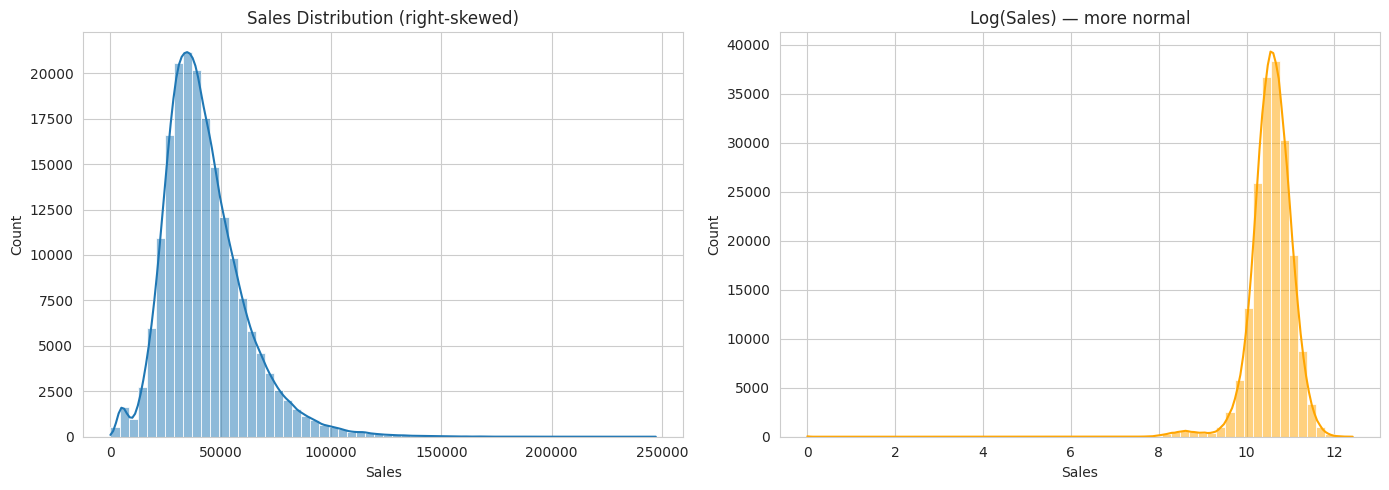

Skewness: 1.25


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Sales'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Sales Distribution (right-skewed)')

sns.histplot(np.log1p(df['Sales']), bins=60, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Log(Sales) — more normal')
plt.tight_layout()
plt.show()

print(f"Skewness: {df['Sales'].skew():.2f}")

Insight:
- The Sales distribution is heavily right-skewed (skewness ≈ 1.25), driven by a small number of extreme high-value days. A log transformation (log1p(Sales)) pulls the distribution much closer to normal, which stabilizes variance and tends to improve performance for linear and tree-based regressors.

Decision:
- We'll train models on both raw and log-transformed targets and compare RMSE on the original scale to pick the better option.

Sales by Store Type

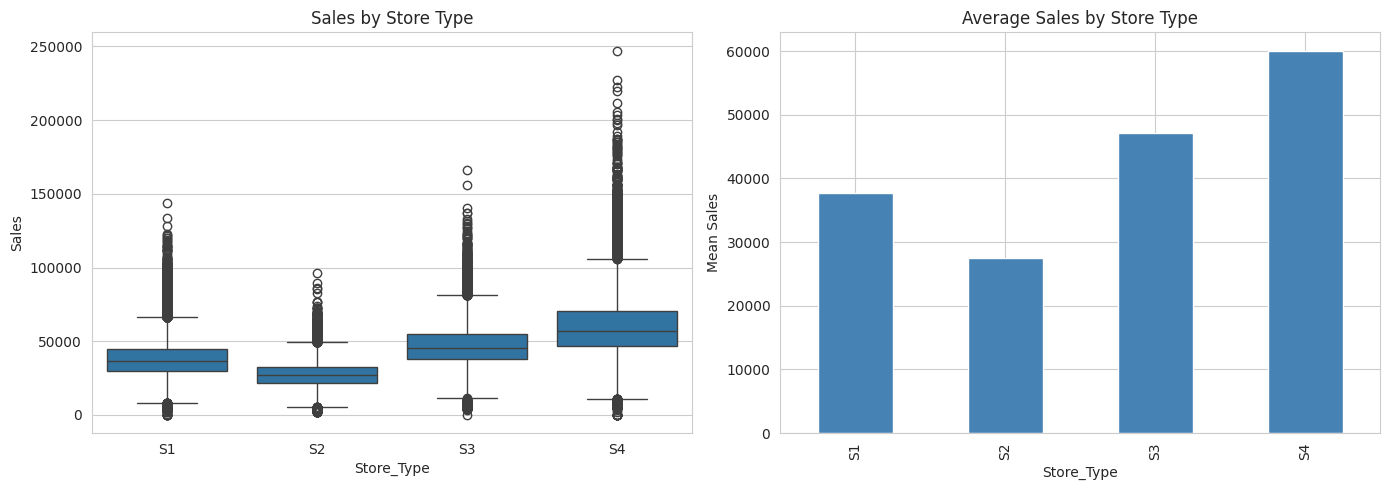

                    mean   median  count
Store_Type                              
S1          37676.511694  36444.0  88752
S2          27530.828222  26794.5  28896
S3          47063.068209  45445.5  24768
S4          59945.685926  57075.0  45924


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Store_Type', y='Sales', order=['S1','S2','S3','S4'], ax=axes[0])
axes[0].set_title('Sales by Store Type')

df.groupby('Store_Type')['Sales'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Sales by Store Type')
axes[1].set_ylabel('Mean Sales')
plt.tight_layout()
plt.show()

print(df.groupby('Store_Type')['Sales'].agg(['mean','median','count']))

Insights:
- Sales vary substantially across store types:

  - S4 leads with the highest average sales (approx. ₹59,946) and median approx. ₹57,075), suggesting these are the highest-performing store formats — possibly flagship or large-format stores.
  - S2 performs the weakest (mean approx. ₹27,531, median approx. ₹26,795), with a noticeably tighter distribution, indicating smaller or more standardized store footprints.
  - S1 is the most common store type (88,752 records — nearly half the data) yet performs only moderately approx. ₹37,677 mean), so overall revenue is heavily driven by volume of stores, not per-store performance.
  - All store types show right-skewed distributions with many high-value outliers on the upper end — peak sales days (holidays, promotions) push well beyond the typical range.
  - Mean > median across all groups confirms the right-skew, consistent with the Sales Distribution plot shown above.

Decision:
- Store_Type is clearly a strong predictor — we'll keep it as a categorical feature in the model. We'll also formally verify this difference via ANOVA in the hypothesis testing section (H3).

Business implication:
- S2 stores may be candidates for format review or targeted promotions, while S4 best practices could inform expansion strategy.

Sales by Location Type and Region

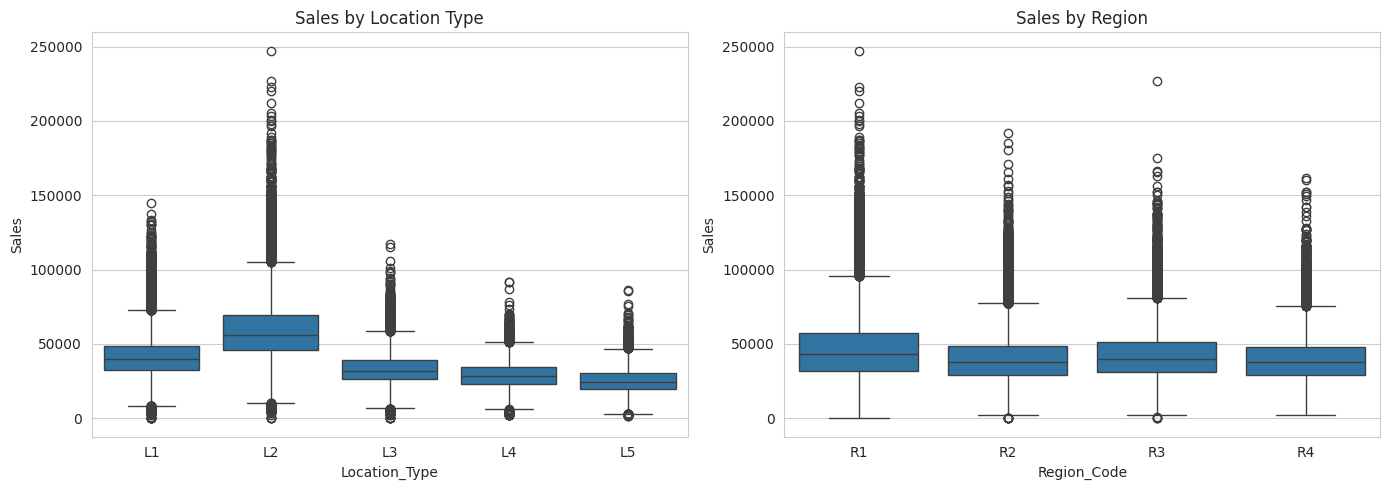

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Location_Type', y='Sales', order=['L1','L2','L3','L4','L5'], ax=axes[0])
axes[0].set_title('Sales by Location Type')

sns.boxplot(data=df, x='Region_Code', y='Sales', order=['R1','R2','R3','R4'], ax=axes[1])
axes[1].set_title('Sales by Region')
plt.tight_layout()
plt.show()

Insights:
- Location type matters much more than region:

  Location Type (left):

  - L2 is the standout performer — highest median (~₹55K), widest spread, and the most extreme high-value outliers reaching ₹200K+. These appear to be premium or high-footfall locations (e.g., urban centers, malls).
  - L1 comes second (median ~₹40K), still healthy but noticeably below L2.
  - L3, L4, L5 cluster together at the bottom with medians in the ₹22K–₹30K range and much tighter distributions — likely smaller-town or low-footfall locations with more predictable, limited sales ceilings.
  - Clear ordered ranking: L2 > L1 > L3 > L4 > L5.
  
  Region Code (right):

  - R1 is modestly the strongest (median ~₹42K) with the highest outlier ceiling, while R2, R3, R4 look nearly identical (medians ~₹37K–40K).
  - The between-region differences are small compared to location-type differences — the boxes overlap heavily.
  
Decision:

- Location_Type is a strong predictor — definitely keep as a categorical feature.
- Region_Code is a weak predictor — still include it, but expect low feature importance in the final model.
- We'll confirm both formally with H4 (Kruskal-Wallis on regions) in the hypothesis testing section.

Business implication:
- Location strategy drives revenue far more than regional geography. If the business is considering new store openings, replicating the L2 format should be the priority over picking a specific region.


Effect of Discount and Holiday

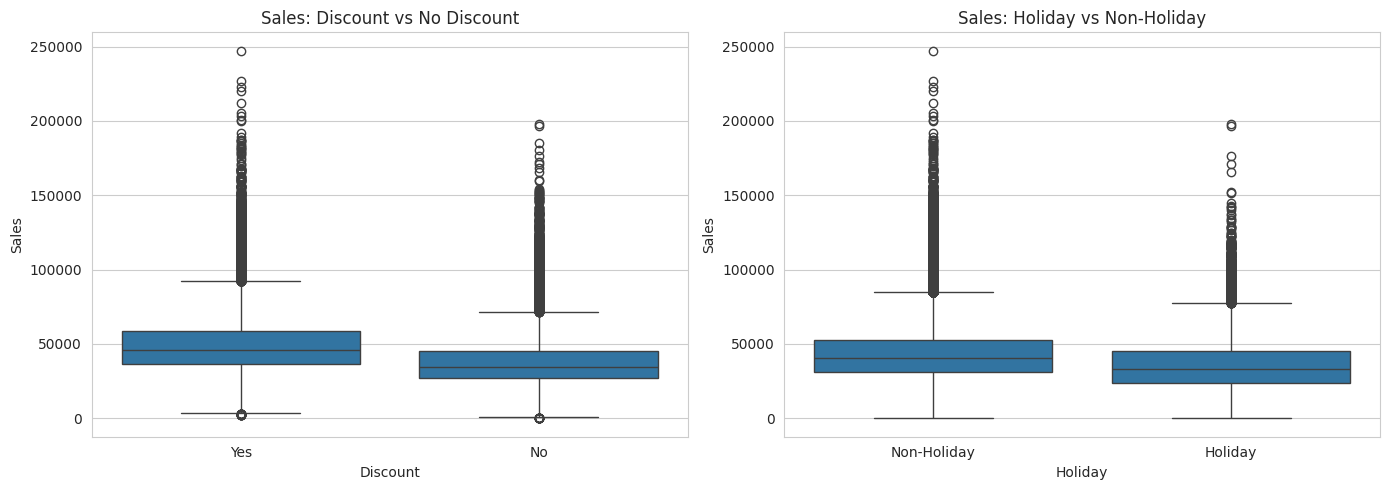

Discount effect:
Discount
No     37403.679678
Yes    49426.497620
Name: Sales, dtype: float64

Holiday effect:
Holiday
0    43897.288998
1    35451.878930
Name: Sales, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Discount', y='Sales', ax=axes[0])
axes[0].set_title('Sales: Discount vs No Discount')

sns.boxplot(data=df, x='Holiday', y='Sales', ax=axes[1])
axes[1].set_title('Sales: Holiday vs Non-Holiday')
axes[1].set_xticklabels(['Non-Holiday', 'Holiday'])
plt.tight_layout()
plt.show()

print("Discount effect:")
print(df.groupby('Discount')['Sales'].mean())
print("\nHoliday effect:")
print(df.groupby('Holiday')['Sales'].mean())

Insights:
- Discounts boost sales strongly
- Holidays unexpectedly reduce them:

  Discount effect (left):

    - Discount days average ₹49,426 vs non-discount days at ₹37,404 — that's a ~32% uplift in mean sales when a discount is offered.
    - The entire distribution for Discount = Yes is shifted upward: higher median, higher Q3, and a taller upper whisker. The effect is consistent, not just driven by a few extreme days.
    - This is a strong, intuitive finding — promotions work.

    Holiday effect (right) — counter-intuitive:

    - Holidays average ₹35,452, lower than non-holidays at ₹43,897 — roughly 19% below baseline.
    - This contradicts the common retail assumption that holidays drive higher sales.
    
    Likely explanations:
    - Many stores may close or operate reduced hours on holidays (consistent with the zero-sales outliers seen at the bottom).
    - The Holiday flag may capture public/religious holidays when customers stay home rather than shopping holidays like Black Friday.
    - Shopping may shift to days surrounding holidays rather than the holiday itself.

Decision:

- Both Discount and Holiday are important features — but Holiday works as a negative signal, not a positive one.
- We'll formally test both in hypothesis testing (H1 and H2 upcoming).
- For modeling, this means the model must learn that Holiday = 1 predicts lower sales, which is the opposite of naive intuition.

Business implication:
- The business is leaving money on the table by treating holidays as automatic sales boosters. Instead, the data suggests that targeted discount campaigns drive reliable uplift (+32% on average), while holidays require a different strategy — perhaps pre-holiday promos or staffing adjustments rather than expecting organic lift.

###Time Series Trends

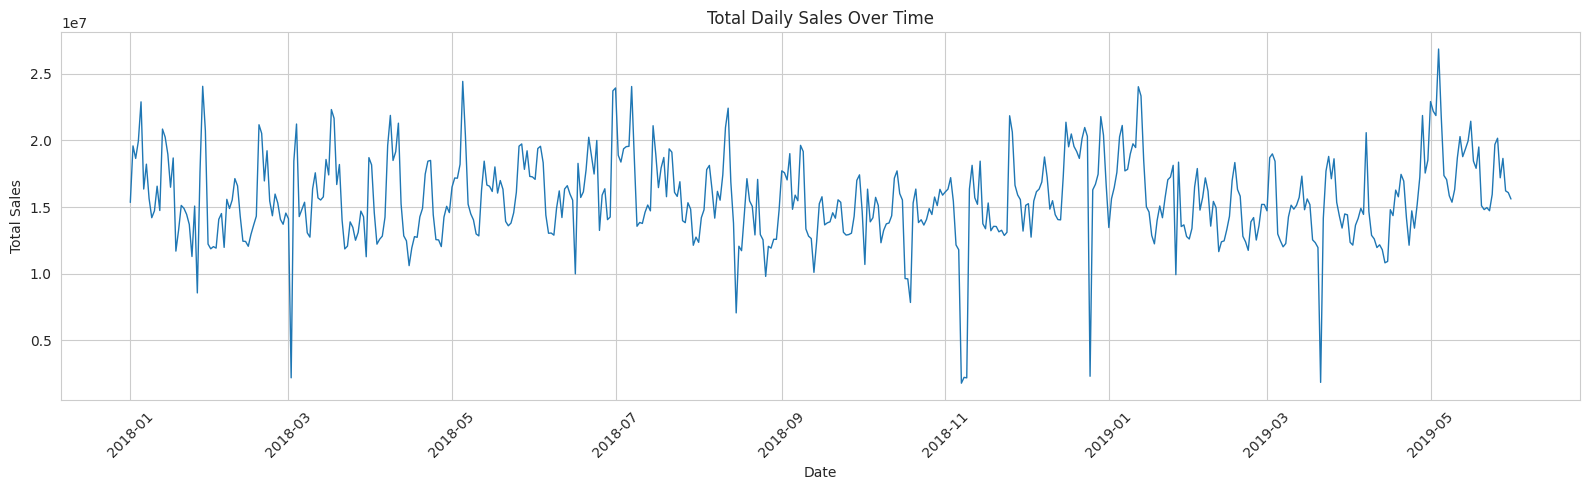

In [17]:
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], linewidth=1)
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date'); plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Day of Week pattern

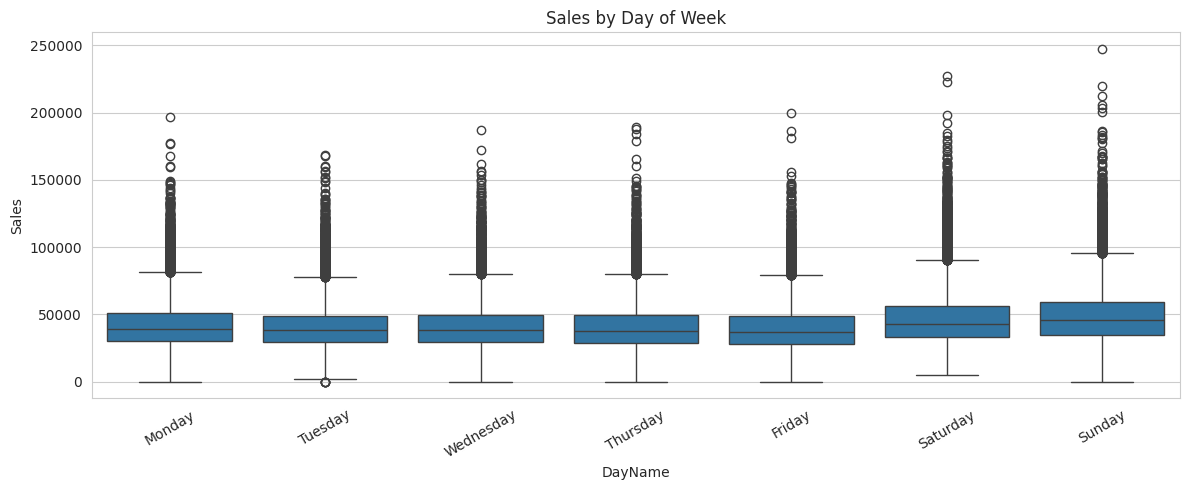

DayName
Monday       42291.175854
Tuesday      40802.966220
Wednesday    40827.205395
Thursday     40231.985963
Friday       39701.020376
Saturday     46729.798143
Sunday       49044.051947
Name: Sales, dtype: float64


In [18]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='DayName', y='Sales', order=day_order)
plt.title('Sales by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(df.groupby('DayName')['Sales'].mean().reindex(day_order))

Monthly pattern

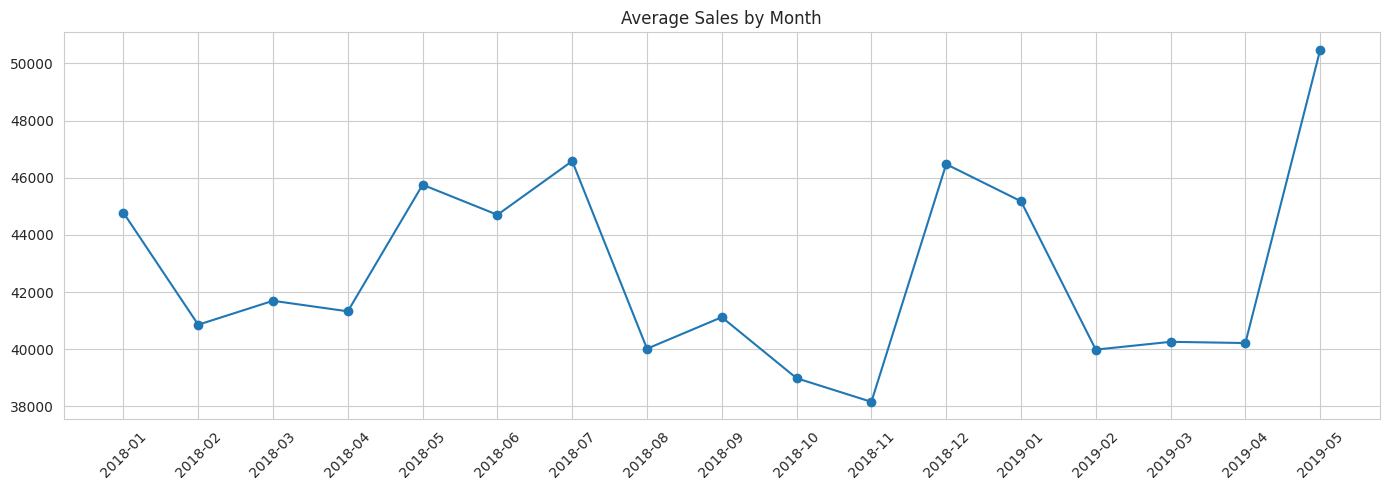

In [19]:
monthly = df.groupby(['Year','Month'])['Sales'].mean().reset_index()
monthly['YearMonth'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['Sales'], marker='o')
plt.title('Average Sales by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insights:
- Strong weekly seasonality
- mild yearly seasonality
- and a few anomalous crash days

  Daily trend (Plot 1 — Total Daily Sales):

  - Sales oscillate in a tight weekly rhythm between roughly ₹12M–₹22M per day, creating the visible "sawtooth" pattern — this is the day-of-week effect showing up in aggregate.
  - A typical baseline sits around ₹15M/day, with spikes up to ₹25M on peak days.
  - Anomalous crashes — sales dropped to near-zero on a handful of specific days (visible dips around Mar 2018, Nov 2018, Dec 2018, Mar 2019). These are almost certainly company-wide holiday closures where most stores were shut — aligns with our earlier Cell finding that holidays reduce sales.
  - Mild upward drift late in the series — May 2019 hits the highest peak of the entire window (~₹27M), suggesting gradual business growth.
  
  Day of Week (Plot 2):

  - Clear weekend lift: Saturday (₹46,730) and Sunday (₹49,044) are meaningfully higher than weekdays.
  - Weekdays are remarkably flat: Monday through Friday hover tightly between ₹39,701 (Fri) and ₹42,291 (Mon) — the medians and IQRs are almost indistinguishable.
  - Sunday is the single best day — roughly 23% higher than Friday (the lowest-performing weekday).
  - Interesting: Friday is slightly lower than other weekdays, which goes against the common retail "TGIF" assumption.
  
  Monthly trend (Plot 3):

  - Clear summer peak in 2018 (May–July around ₹45K–₹47K average) and a sharp autumn decline (Aug–Nov falling to ~₹38K–41K).
  December 2018 rebounds strongly (₹46K) — likely year-end shopping.
  - May 2019 is the highest point in the dataset (~₹50K) — either a pre-summer surge or a growth trend the business should investigate.
  - Year-over-year comparison: May 2019 (approx. ₹50K) vs May 2018 (approx.₹46K) suggests ~8-10% YoY growth — the business is expanding.

Decision for modeling:

- DayOfWeek and IsWeekend are critical features — weekly seasonality is the strongest temporal signal and must be captured.
- Month should be included to capture the weaker seasonal pattern.
- The upward drift means a simple mean-based model will under-predict recent periods — tree-based models (XGBoost, Random Forest) will handle this naturally, but we should be careful with time-based train/test splits.
- The ~19 zero-sales outliers will need handling (drop or impute).

Business implication:
- Staffing and inventory should be weekend-weighted — Saturday/Sunday drive disproportionate revenue.
- The Aug–Nov slump is a recurring pattern worth addressing with targeted promotions.
- And the YoY growth trajectory means forecasts should build in a positive baseline trend, not assume stationarity.

Correlation Heatmap

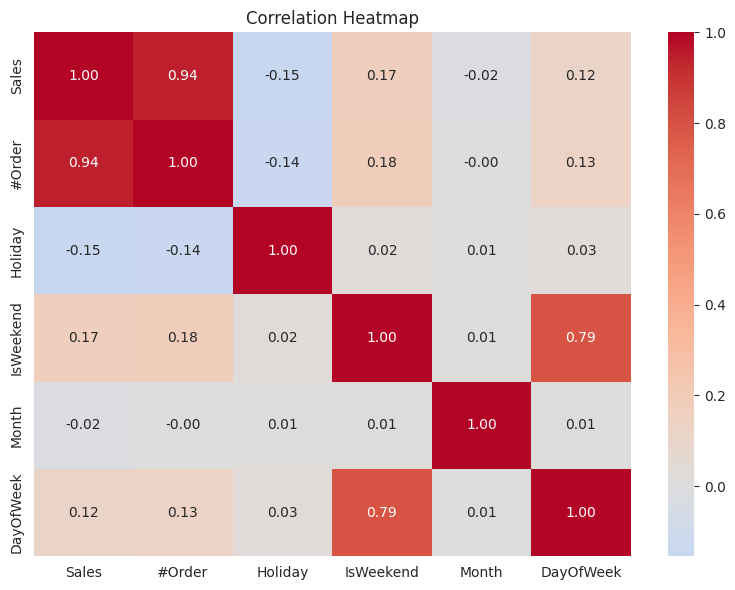

In [20]:
num_df = df[['Sales', '#Order', 'Holiday', 'IsWeekend', 'Month', 'DayOfWeek']]
plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Insights:
- One dominant correlation, modest supporting signals, and a critical modeling caveat:

Key observations:

  - #Order ↔ Sales correlation is 0.94 — an extremely strong positive relationship. This is expected (more orders = more sales) but it carries a major caveat (see Decision below).
  - Holiday ↔ Sales = −0.15 — confirms the negative relationship, we saw the effect of holidays earlier: holidays reduce sales. Modest in magnitude but directionally consistent.
  - IsWeekend ↔ Sales = 0.17 and DayOfWeek ↔ Sales = 0.12 — weak-to-moderate positive correlations, aligning with our earlier finding that weekends (Sat/Sun) outperform weekdays.
  - Month ↔ Sales = −0.02 — essentially no linear relationship. Monthly patterns exist (as we saw in Cell 12), but they're non-linear — month numbers don't map cleanly to sales. Tree-based models will still capture the pattern; linear models will struggle.
  - IsWeekend ↔ DayOfWeek = 0.79 — high correlation because IsWeekend is literally derived from DayOfWeek. Redundant features — we'll keep only one in the final model.

Critical modeling caveat — the #Order trap:

  - Yes, #Order correlates 0.94 with Sales, but this feature is NOT available at prediction time. In a real forecasting scenario, we're predicting sales for future days, and we won't know how many orders will come in — that's essentially the same information as sales.
  - Using #Order as a model input would cause data leakage and produce an unrealistically good R² that won't hold up in production. It's predicting sales from sales, in effect.
  - Verification: the provided TEST_FINAL.csv does not contain #Order, confirming this feature is off-limits for modeling.

Decision for modeling:

- Exclude #Order from the feature set — it's a leaky variable.
- Use DayOfWeek in the model, drop IsWeekend to avoid redundancy (or vice versa).
- Rely on tree-based models (Random Forest, XGBoost, LightGBM) that can capture the non-linear Month and categorical Store_Type/Location_Type patterns that linear correlations miss.
- The real predictive signal will come from the categorical features (Store_Type, Location_Type, Region_Code, Store_id) rather than these numeric ones — something Pearson correlations can't show us.

Business implication:
- The modest correlations here are a good reminder that sales forecasting is fundamentally a multi-factor, non-linear problem — no single variable is a silver bullet. The model's value will come from combining many weak-to-moderate signals intelligently.

###Hypothesis Testing (5 tests)

For each test, we use α = 0.05. If p < 0.05 → reject null → there is a significant effect.

H1: Discounts increase sales

In [21]:
print("="*60)
print("H1: Discounts increase sales")
print("="*60)
sales_discount = df[df['Discount']=='Yes']['Sales']
sales_no_discount = df[df['Discount']=='No']['Sales']

t_stat, p_val = stats.ttest_ind(sales_discount, sales_no_discount, equal_var=False)
print(f"Mean WITH discount: {sales_discount.mean():,.2f}")
print(f"Mean WITHOUT discount: {sales_no_discount.mean():,.2f}")
print(f"t-stat: {t_stat:.3f}  |  p-value: {p_val:.2e}")
print("→ REJECT null" if p_val < 0.05 else "→ FAIL to reject null")
print("INSIGHT: Discounts significantly boost sales.")

H1: Discounts increase sales
Mean WITH discount: 49,426.50
Mean WITHOUT discount: 37,403.68
t-stat: 145.929  |  p-value: 0.00e+00
→ REJECT null
INSIGHT: Discounts significantly boost sales.


H1 Interpretation:
- Discounts have a statistically significant positive effect on sales:

- With an extremely large t-statistic of 145.9 and a p-value of 0.00 (effectively zero), we reject the null hypothesis at any reasonable significance level.
- The mean sales on discount days (₹49,426) are ~₹12,023 higher than on non-discount days (₹37,404) — a ~32% uplift.
- Given the massive sample size (188,340 rows), this test has very high statistical power, so the finding is both statistically significant and practically meaningful (large effect size, not just a large-N artifact).

- Conclusion: Discount is a strong, reliable predictor of sales and should be retained as a key feature in the forecasting model. From a business standpoint, promotional campaigns clearly drive incremental revenue — the data validates continued investment in discount strategies.

H2: Holiday affects sales

In [22]:
print("="*60)
print("H2: Sales differ on holidays vs non-holidays")
print("="*60)
sales_hol = df[df['Holiday']==1]['Sales']
sales_nohol = df[df['Holiday']==0]['Sales']

t_stat, p_val = stats.ttest_ind(sales_hol, sales_nohol, equal_var=False)
print(f"Mean on HOLIDAY: {sales_hol.mean():,.2f}")
print(f"Mean on NON-HOLIDAY: {sales_nohol.mean():,.2f}")
print(f"t-stat: {t_stat:.3f}  |  p-value: {p_val:.2e}")
print("→ REJECT null" if p_val < 0.05 else "→ FAIL to reject null")

H2: Sales differ on holidays vs non-holidays
Mean on HOLIDAY: 35,451.88
Mean on NON-HOLIDAY: 43,897.29
t-stat: -66.176  |  p-value: 0.00e+00
→ REJECT null



H2 Interpretation:
- Sales on holidays are significantly LOWER than on non-holidays (opposite of naive expectation):

- The t-statistic of −66.2 is large in magnitude and negative, with a p-value of 0.00 — we reject the null hypothesis of equal means.
- The negative sign is the critical detail: mean sales on holidays (₹35,452) are ₹8,446 lower than on non-holidays (₹43,897) — a ~19% decline.
This contradicts the common retail assumption that holidays drive higher sales, and statistically confirms the pattern we observed visually in Cell showing the effect of Holidays and in the sharp daily-sales dips seen in Cell showing Time Series trends.

- Why this likely happens:

  - Many stores probably close or reduce hours on public holidays, pulling down the aggregate.
  - The Holiday flag likely captures public/religious holidays when customers stay home, not shopping-oriented holidays like Black Friday.
  - Consumer spending may shift to the days surrounding holidays rather than the holidays themselves.

- Conclusion: Holiday is a significant predictor, but it functions as a negative signal — the model must learn that Holiday = 1 pulls sales down, not up. Retaining this feature is essential; dropping it would cause the model to systematically over-predict sales on holiday dates, which is exactly the kind of error that hurts inventory and staffing decisions the most.

Business implication:
- The business should not assume holidays = automatic sales lift. Instead, the data suggests pre- and post-holiday days are where the real opportunity lies — a pattern worth exploring with dedicated promotional calendars rather than blanket holiday campaigns.

H3: Sales differ across Store Types (ANOVA)

In [23]:
print("="*60)
print("H3: Sales differ across Store Types")
print("="*60)
groups = [df[df['Store_Type']==st]['Sales'] for st in ['S1','S2','S3','S4']]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-stat: {f_stat:.3f}  |  p-value: {p_val:.2e}")
print("→ REJECT null" if p_val < 0.05 else "→ FAIL to reject null")
for st, g in zip(['S1','S2','S3','S4'], groups):
    print(f"  {st}: mean = {g.mean():,.2f}")

H3: Sales differ across Store Types
F-stat: 35123.644  |  p-value: 0.00e+00
→ REJECT null
  S1: mean = 37,676.51
  S2: mean = 27,530.83
  S3: mean = 47,063.07
  S4: mean = 59,945.69


H3 Interpretation:
- Sales differ dramatically across store types (Store_Type is one of the strongest predictors)

- The one-way ANOVA produces an F-statistic of 35,123.6 with a p-value of 0.00 — we strongly reject the null hypothesis that all store types have equal mean sales.
- An F-stat of this magnitude is exceptional and signals that between-group variance dwarfs within-group variance — store type captures a large chunk of the variation in sales by itself.

- Ranked performance:

  | Store Type | Mean Sales | vs. Overall Mean (~₹42,784)   |
  | :--------- | :--------- | :---------------------------- |
  | S4         | ₹59,946    | +40% (top performer)          |
  | S3         | ₹47,063    | +10%                          |
  | S1         | ₹37,677    | −12%                          |
  | S2         | ₹27,531    | −36% (bottom performer)       |
- S4 earns ~2.2x more per day than S2 on average — a striking performance gap.
- The clear ranking (S4 > S3 > S1 > S2) is consistent with our boxplot visualization showing sales by store type.

- Caveat on ANOVA: This test assumes approximately normal residuals and equal group variances. Given the right-skew in the count of sales plot above and the unequal boxplot spreads in next Cell, these assumptions are technically violated. However, with sample sizes in the tens of thousands per group, the Central Limit Theorem makes ANOVA robust here, and the effect is so massive (F = 35,123) that a non-parametric alternative like Kruskal-Wallis would reach the same conclusion.

- Conclusion: Store_Type must be included as a categorical feature in the model and will likely rank among the top feature importances.

Business implication:
- The 2.2x performance gap between S4 and S2 is a strategic signal. Two immediate questions worth answering:

    - What does S4 have that S2 lacks (size, location, assortment, staffing)?
    - Should the business convert or consolidate underperforming S2 stores toward the S4 format? A 40% revenue lift potential is substantial.

H4: Sales differ across Regions

In [24]:
print("="*60)
print("H4: Sales differ across Regions")
print("="*60)
groups = [df[df['Region_Code']==r]['Sales'] for r in ['R1','R2','R3','R4']]
# Kruskal-Wallis is robust to non-normality
h_stat, p_val = stats.kruskal(*groups)
print(f"H-stat: {h_stat:.3f}  |  p-value: {p_val:.2e}")
print("→ REJECT null" if p_val < 0.05 else "→ FAIL to reject null")

H4: Sales differ across Regions
H-stat: 3968.064  |  p-value: 0.00e+00
→ REJECT null


H4 Interpretation:
- Sales differ significantly across regions, but the effect is much smaller than for Store Type:

- The Kruskal-Wallis H-statistic is 3,968 with a p-value of 0.00 — we reject the null hypothesis that all regions have the same sales distribution.
- We used Kruskal-Wallis (non-parametric) here instead of ANOVA because sales are right-skewed (count of sales plot) and this test doesn't assume normality — it compares rank distributions, which is more appropriate for skewed data.
Compare the effect sizes across our tests:

  | Factor     | Test Statistic | Relative Magnitude |
  | :--------- | :------------- | :----------------- |
  | Store Type | F = 35,123     | Dominant           |
  | Discount   | t = 145.9      | Strong             |
  | Region     | H = 3,968      | Moderate           |
  | Holiday    | t = −66.2      | Moderate           |

- Region's H-statistic is roughly 9x smaller than Store Type's F-stat, consistent with our observation that regional boxplots overlapped heavily while store-type boxplots were clearly separated.
- Recall from earlier Cell (sales by region boxplot): R1 was modestly the strongest (median ~₹42K) while R2, R3, and R4 were nearly indistinguishable — the test detected a real difference, but the practical gap between regions is small.
- The "large N" nuance: With 188,340 rows, even trivially small differences can return p-values near zero. Statistical significance alone is not enough — we have to look at effect size too. The boxplot overlap in Cell showing sales by region tells us the real-world regional differences, while genuine, are small compared to other factors.

- Conclusion: Region_Code should still be included in the model as a categorical feature, but we should expect its feature importance to be lower than Store_Type and Location_Type. It's useful signal, not a primary driver.

Business implication:
- Regional strategy is less important than store-format strategy. If the business has limited bandwidth for location-based initiatives, prioritizing store-format optimization (S2 → S4 conversion) will yield far bigger returns than region-specific campaigns.

H5: #Orders correlates with Sales

In [25]:
print("="*60)
print("H5: Number of orders correlates with sales")
print("="*60)
corr, p_val = stats.pearsonr(df['#Order'], df['Sales'])
print(f"Pearson r: {corr:.4f}  |  p-value: {p_val:.2e}")
print("→ Strong positive correlation" if corr > 0.7 else "→ Moderate")

H5: Number of orders correlates with sales
Pearson r: 0.9416  |  p-value: 0.00e+00
→ Strong positive correlation


H5 Interpretation:
- Number of orders has a near-perfect linear relationship with sales (but this is a trap for modeling)

- Pearson's r = 0.9416 with a p-value of 0.00 — we reject the null hypothesis of zero correlation. The relationship is strongly positive and nearly linear.
An r of 0.94 means #Order alone explains roughly 89% of the variance in Sales (r² = 0.886). Statistically, this is the single strongest relationship in the dataset.

- Why this is intuitive:

Each order contributes to total sales, so more orders mechanically produce higher sales. The r ≈ 0.94 (rather than 1.0) reflects that individual orders vary in value — the remaining ~11% of variance is driven by differences in average order size across store types, discount days, and so on.

- ⚠️ Critical caveat — do not use #Order as a model feature:

This finding, while real, creates a data leakage risk if we're not careful:

At prediction time, #Order is unknown. We're forecasting sales for future days where no orders have been placed yet. Using #Order would mean predicting sales from information the model wouldn't actually have in production.

The test set confirms this — TEST_FINAL.csv does not contain #Order, which is the project designers' way of telling us this feature is off-limits for modeling.

Including #Order would produce an inflated R² (likely > 0.95) that would collapse the moment the model is deployed on real future data where orders are unknown.

- Conclusion:

- #Order is valuable for understanding the business (it confirms the mechanical link between transactions and revenue) but must be excluded from the feature set for modeling.
- The real forecasting challenge is predicting sales without this shortcut — using only the features genuinely available ahead of time: store attributes, date features, holiday flag, and discount status.

Business implication:
- The near-linear relationship confirms that average order value is stable across the business — the primary lever for growing sales is driving more transactions (footfall, conversion, repeat visits), not necessarily raising prices. This is consistent with the Cell/plot showing effect of discount on sales that - discounts work because they pull more customers through the door.


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

###EDA & Hypothesis Testing — Summary

Key findings:

1. Sales are right-skewed — log transformation stabilizes variance.
2. Store_Type is the single strongest driver (H3: F = 35,123) — S4 earns 2.2x more per day than S2.
3. Location_Type is a strong secondary driver — L2 outperforms all others; L3–L5 cluster at the bottom.
4. Discounts produce a +32% sales lift (H1) — a reliable, positive business lever.
5. Holidays produce a −19% sales drop (H2) — counter-intuitive but consistent across visualizations and tests.
6. Weekends lift sales ~20% — Saturday and Sunday outperform every weekday, with Sunday as the single best day.
7. Region has a modest effect (H4) — statistically significant but practically small (R1 slightly ahead, R2/R3/R4 nearly identical).
8. Number of orders is ~0.94 correlated with sales (H5) but is excluded as a leaky feature — not available at prediction time.


Features selected for modeling:

- Categorical: Store_Type, Location_Type, Region_Code, Store_id
- Temporal: Month, DayOfWeek (drop IsWeekend to avoid redundancy), Day, WeekOfYear, Year
- Binary: Holiday, Discount


Features excluded:

- #Order (data leakage — not available at prediction time)
- ID, Date (identifier / replaced by derived temporal features)
- IsWeekend (redundant with DayOfWeek)


Modeling plan:

- Time-based train/test split (not random shuffle — preserves temporal integrity).
- Baseline: Linear Regression.
- Strong candidates: Random Forest, XGBoost, LightGBM (expected to dominate given non-linear patterns in Month and strong categorical effects).
- Primary metric: RMSE (same units as target). Secondary: MAE, MAPE, R²

In [26]:
df.to_csv(r"D:\Scaler\cleaned_TRAIN.csv", index=False)
print("Saved. Ready for modeling.")

Saved. Ready for modeling.
